In [21]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


print(sys.executable)
print("PyTorch:", torch.__version__)
print("Device:", "CUDA" if torch.cuda.is_available() else "CPU")

/home/kethe/AI_projects/higgs_ml/.venv/bin/python
PyTorch: 2.14.0+cpu
Device: CPU


In [2]:
df = pd.read_csv("../data/training.csv")

feature_columns = [
    column
    for column in df.columns
    if column not in ["EventId", "Weight", "Label"]
]

X = df[feature_columns].replace(-999, np.nan)
y = (df["Label"] == "s").astype(int)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

In [4]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

In [5]:
X_train_processed = imputer.fit_transform(X_train_model)
X_val_processed = imputer.transform(X_val)
X_test_processed = imputer.transform(X_test)

In [6]:
X_train_processed = scaler.fit_transform(X_train_processed)
X_val_processed = scaler.transform(X_val_processed)
X_test_processed = scaler.transform(X_test_processed)

In [7]:
X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train_model.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

X_val_tensor = torch.tensor(
    X_val_processed,
    dtype=torch.float32,
)

y_val_tensor = torch.tensor(
    y_val.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32,
)

y_test_tensor = torch.tensor(
    y_test.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([160000, 30])
torch.Size([160000, 1])


In [8]:
class HiggsNetwork(nn.Module):

    def __init__(self, n_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)

In [9]:
model = HiggsNetwork(
    n_features=X_train_tensor.shape[1]
)

print(model)

HiggsNetwork(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [10]:
loss_function = nn.BCEWithLogitsLoss()

In [11]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
)

In [12]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
)

In [13]:
model.train()

for X_batch, y_batch in train_loader:

    optimizer.zero_grad()

    logits = model(X_batch)

    loss = loss_function(
        logits,
        y_batch,
    )

    loss.backward()

    optimizer.step()

In [14]:
def train_one_epoch(model, loader, optimizer, loss_function):

    model.train()

    total_loss = 0.0

    for X_batch, y_batch in loader:

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = loss_function(
            logits,
            y_batch,
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * len(X_batch)

    return total_loss / len(loader.dataset)

In [15]:
loss_history = []

for epoch in range(10):

    loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        loss_function,
    )

    loss_history.append(loss)

    print(
        f"Epoch {epoch + 1:2d} | "
        f"Loss = {loss:.4f}"
    )

Epoch  1 | Loss = 0.3959
Epoch  2 | Loss = 0.3805
Epoch  3 | Loss = 0.3739
Epoch  4 | Loss = 0.3698
Epoch  5 | Loss = 0.3665
Epoch  6 | Loss = 0.3642
Epoch  7 | Loss = 0.3620
Epoch  8 | Loss = 0.3600
Epoch  9 | Loss = 0.3585
Epoch 10 | Loss = 0.3575


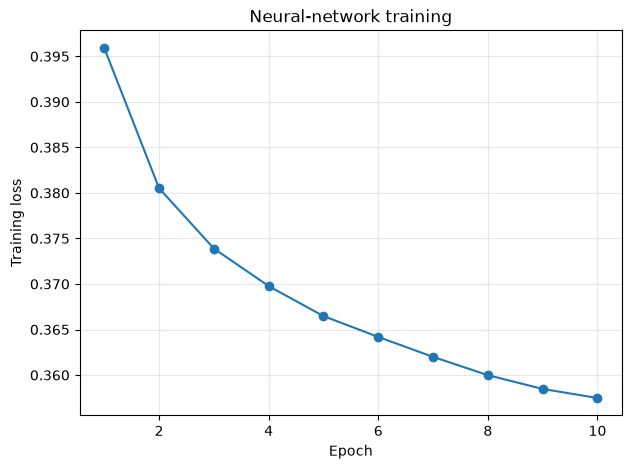

In [17]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, len(loss_history) + 1),
    loss_history,
    marker="o",
)

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Neural-network training")
plt.grid(alpha=0.3)

plt.show()

In [18]:
def predict_probability(model, X):

    model.eval()

    with torch.no_grad():
        logits = model(X)
        probabilities = torch.sigmoid(logits)

    return probabilities.numpy().ravel()

In [19]:
nn_val_score = predict_probability(
    model,
    X_val_tensor,
)

In [20]:
nn_val_auc = roc_auc_score(
    y_val,
    nn_val_score,
)

print(f"Neural network validation AUC: {nn_val_auc:.4f}")

Neural network validation AUC: 0.9067


In [22]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000)),
])

logistic_model.fit(X_train_model, y_train_model)
logistic_val_score = logistic_model.predict_proba(X_val)[:, 1]
logistic_val_auc = roc_auc_score(
    y_val,
    logistic_val_score,
)

print(f"Logistic regression validation AUC: {logistic_val_auc:.4f}")

Logistic regression validation AUC: 0.8166


In [23]:
final_tree = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42,
)

final_tree.fit(X_train_model, y_train_model)
tree_val_score = final_tree.predict_proba(X_val)[:, 1]
tree_val_auc = roc_auc_score(
    y_val,
    tree_val_score,
)

print(f"Boosted-tree validation AUC: {tree_val_auc:.4f}")

Boosted-tree validation AUC: 0.9102


In [24]:
results = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "Boosted trees",
        "Neural network",
    ],
    "Validation ROC-AUC": [
        logistic_val_auc,
        tree_val_auc,
        nn_val_auc,
    ],
})

results

,Model,Validation ROC-AUC
0,Logistic regression,0.816616
1,Boosted trees,0.910242
2,Neural network,0.906656


In [25]:
nn_fpr, nn_tpr, _ = roc_curve(
    y_val,
    nn_val_score,
)

tree_fpr, tree_tpr, _ = roc_curve(
    y_val,
    tree_val_score,
)

log_fpr, log_tpr, _ = roc_curve(
    y_val,
    logistic_val_score,
)

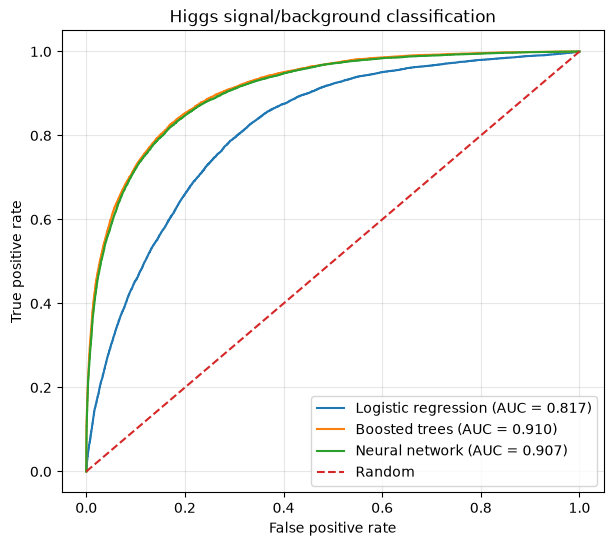

In [26]:
plt.figure(figsize=(7, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic regression (AUC = {logistic_val_auc:.3f})",
)

plt.plot(
    tree_fpr,
    tree_tpr,
    label=f"Boosted trees (AUC = {tree_val_auc:.3f})",
)

plt.plot(
    nn_fpr,
    nn_tpr,
    label=f"Neural network (AUC = {nn_val_auc:.3f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random",
)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Higgs signal/background classification")
plt.legend()
plt.grid(alpha=0.3)

plt.show()